# RadioML 2018.01A — data exploration

Runs the dataset inspection and the constellation sanity check via their notebook API.
Every call accepts a **config name** (e.g. `"baseline"`, `"debug"`) or an explicit `path=`.

In [9]:
import sys, pathlib
# Find the repo root (the folder containing `src/`) and put it FIRST on the import path,
# so this works whether the notebook is launched from notebooks/ or the repo root.
ROOT = pathlib.Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Drop any stale/namespace `scripts`/`src` cached by an earlier failed import, so the
# names below resolve to THIS repo (sys.modules cache otherwise wins over sys.path).
for _m in [m for m in sys.modules if m == 'scripts' or m.startswith('scripts.')
           or m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]

assert (ROOT / 'scripts' / 'inspect_dataset.py').exists(), f"not the repo root: {ROOT}"
print('repo root:', ROOT)

repo root: d:\gok\amc-hardware-domain-shift


## Inspect the dataset

Prints the real structure (shapes, dtypes, class counts, SNR levels, grid check) and
returns a summary `dict`.

In [10]:
from scripts.inspect_dataset import inspect_dataset

summary = inspect_dataset(config='debug')   # or config='baseline', or path='data/GOLD_XYZ_OSC.0001_1024.hdf5'
summary['n_frames'], summary['grid_uniform']

Using config at the path: D:\gok\amc-hardware-domain-shift\configs\debug.yaml
=== FILE ===
path: D:\gok\amc-hardware-domain-shift\data\GOLD_XYZ_OSC.0001_1024.hdf5
keys: ['X', 'Y', 'Z']
  X: shape=(2555904, 1024, 2) dtype=float32
  Y: shape=(2555904, 24) dtype=int64
  Z: shape=(2555904, 1) dtype=int64

=== LABELS ===
n_frames   : 2555904
n_classes  : 24
frame_length: 1024
strict one-hot Y: True
class counts (column index -> canonical name -> count):
   0  OOK         106496
   1  4ASK        106496
   2  8ASK        106496
   3  BPSK        106496
   4  QPSK        106496
   5  8PSK        106496
   6  16PSK       106496
   7  32PSK       106496
   8  16APSK      106496
   9  32APSK      106496
  10  64APSK      106496
  11  128APSK     106496
  12  16QAM       106496
  13  32QAM       106496
  14  64QAM       106496
  15  128QAM      106496
  16  256QAM      106496
  17  AM-SSB-WC   106496
  18  AM-SSB-SC   106496
  19  AM-DSB-WC   106496
  20  AM-DSB-SC   106496
  21  FM          1064

(2555904, True)

## Constellation sanity check

Saves a PNG with a dynamic, self-describing name into `outputs/` **and** displays it
inline. Returns the matplotlib `Figure`.

In [13]:
from scripts.sanity_check import print_class_mapping

print_class_mapping()

=== class index -> modulation (canonical DeepSig order) ===
   0  OOK
   1  4ASK
   2  8ASK
   3  BPSK   <-- expect 2 points
   4  QPSK   <-- expect 4 points
   5  8PSK
   6  16PSK
   7  32PSK
   8  16APSK
   9  32APSK
  10  64APSK
  11  128APSK
  12  16QAM   <-- expect 4x4 grid
  13  32QAM
  14  64QAM
  15  128QAM
  16  256QAM   <-- expect dense 16x16 grid
  17  AM-SSB-WC
  18  AM-SSB-SC
  19  AM-DSB-WC
  20  AM-DSB-SC
  21  FM
  22  GMSK
  23  OQPSK


Using config at the path: D:\gok\amc-hardware-domain-shift\configs\debug.yaml
=== rendering constellations at SNR = 30 dB (sps=8, normalization=unit_power) ===

saved: D:\gok\amc-hardware-domain-shift\notebooks\outputs\constellations_debug_snr30_sps8_unit_power.png
ACCEPTANCE: verify BPSK=2 pts, QPSK=4 pts, 16QAM=4x4, 256QAM~16x16 in the figure.


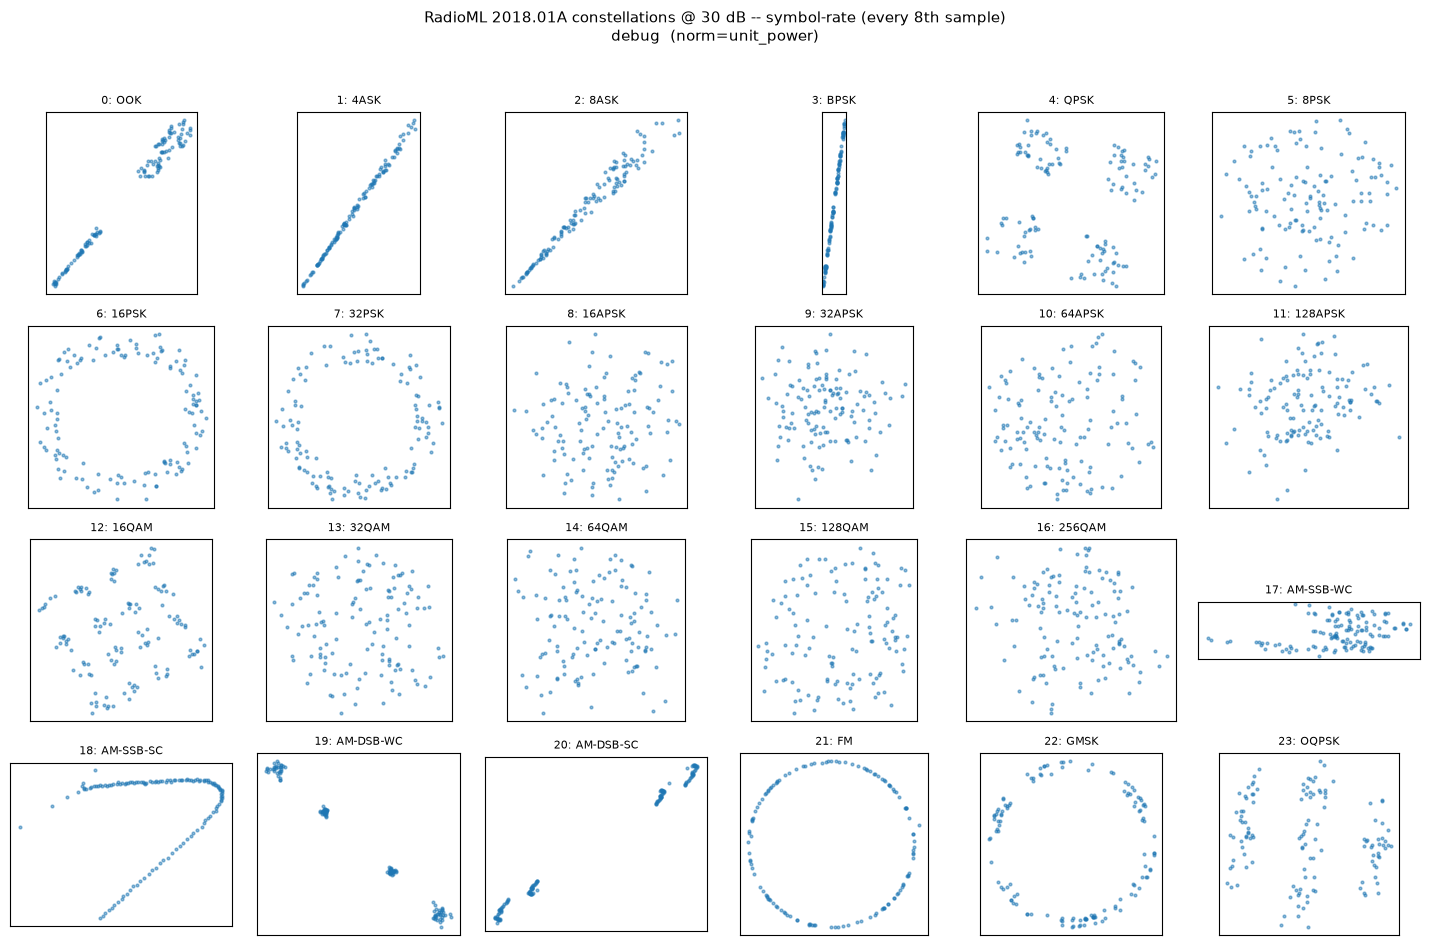

In [11]:
from scripts.sanity_check import plot_constellations

fig = plot_constellations(config='debug')   # defaults: snr=30, sps=8, normalization='unit_power'

### Other options

Pick a different SNR / samples-per-symbol, or point at a specific HDF5 file (e.g. a
subset). `sps=1` shows the raw, pulse-shaped samples instead of the symbol-rate view.

=== rendering constellations at SNR = 30 dB (sps=8, normalization=unit_power) ===

saved: D:\gok\amc-hardware-domain-shift\notebooks\outputs\constellations_GOLD_XYZ_OSC.0001_1024_snr30_sps8_unit_power.png
ACCEPTANCE: verify BPSK=2 pts, QPSK=4 pts, 16QAM=4x4, 256QAM~16x16 in the figure.


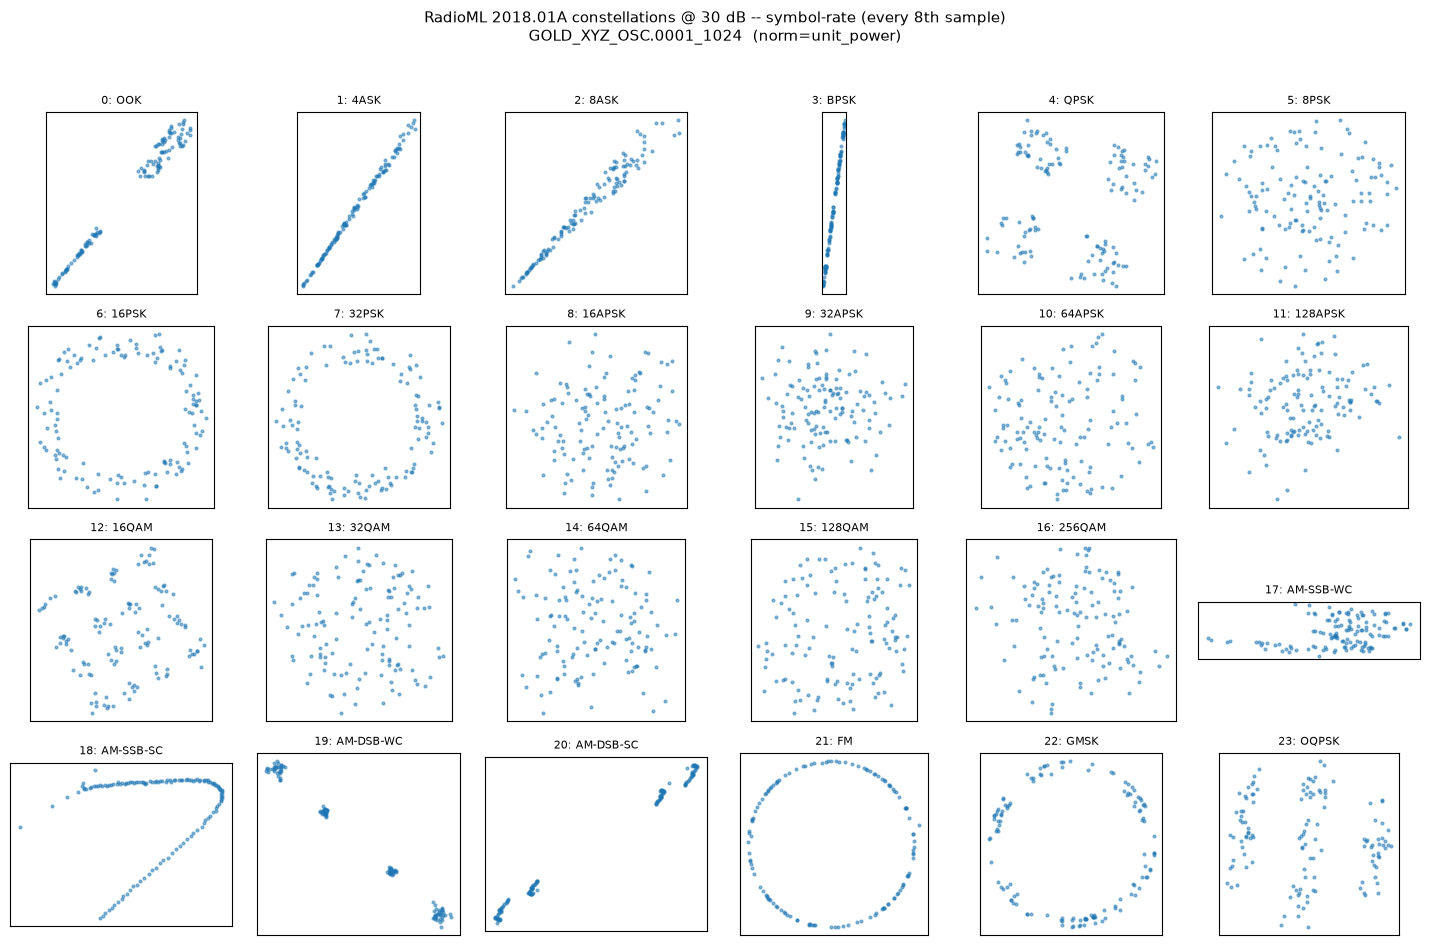

In [12]:
fig = plot_constellations(
    path='data/GOLD_XYZ_OSC.0001_1024.hdf5',
    snr=30, sps=8, normalization='unit_power',
)